# Qualitative Portfolio Optimisation Theory

## Introduction

The goal of this exercise is to create a space on which we can define activities and subsequently measure notions of risk and return of such. From this we can perform Monte Carlo simulations to identify optimal combinations of these activities in what we call a _portfolio_. This document is comprised of five key sections:
1. Defining and Constructing the Feature Space
2. Defining Elements in the Space
3. A Notion of Risk and Return
4. The Risk-Return Scatter Plot
5. The Challenge of Obtaining Meaningful Data

The general framework laid out in this document explores how techniques from both linear algebra and portfolio optimisation can be used to inform resource allocation decisions in disciplines outside of quantitative finance, and in the wider sense of life. Whilst portfolio optimisation in the traditional field of finance is well documented and understood, the application of these techniques to other disciplines is less explored. Although, this is not without good reason; the modelling of qualitative data and subjective notions as purely quantitative measures is an inherently challenging problem; some such challenges are discussed further in section five.

Regardless of the efficacy and practicality of this modelling process, this remains an interesting and though-provoking exercise as to how techniques originally from a quantitative field can be applied to non-standard, qualitative data. It is for this reason we ask the following work be viewed as such, a thought experiment and not as a rigorous proposition.

## 1. Defining and Constructing the Feature Space

In this section we construct notions of certain relevant _features_ of our activities, from which we can represent these activities as linear combinations of. We use the phrase _relevant features_ in particular as one could argue the space of activities is in general infinite dimensional. Or in other words, you cannot describe every possible activity with a finite number of features. So, for this reason we restrict ourselves to only consider the features relevant to the motivating problem; these are:
-  $e_1$ - **net time cost/rebate**; a large positive value represents the activity rewarding/rebating a large amount of time, whereas a large negative value represents the activity requiring a large amount of time (either directly or in the form of opportunity cost).
- $e_2$ - **net monetary cost/gain**; a large positive value represents the activity rewarding a large amount of money, whereas a large negative value represents the activity costing a large amount of money (again, either directly or in the form of opportunity cost).
- $e_3$ - **fulfilment**; a large positive values represents a very fulfilling activity, whereas a large negative value represents a very _empty_/meaningless feeling activity.
- $e_4$ - **enjoyment**; a large positive value represents a very enjoyable activity, whereas a large negative value represents a miserable activity.
- $e_5$ - **social**; a large positive value represents an activity that encourages and improves social interaction, whereas a large negative value represents an isolating activity.

These features can be thought of as the basis vectors spanning our space of activities, in the subsequent section we will go about constructing this basis mathematically, so that correlations between features are encoded into our space. Also, note how these definitions have been constructed in such a way that a positive value typically has a positive association and a negative value a negative association, this allows us to more easily (although still a challenging task) define correlations between features.

*Disclaimer:* Section five of this document explores the challenge of collecting/concluding the unbiased and meaningful data required throughout this process, namely:
1. Correlation values (between -1, 1) for each pair of features, $e_i,e_j$.
2. Position vectors for each element.
3. Weights for risk and return metrics to determine perceived relative importance of each feature in our risk-return calculation.

However, prior to that discussion we simply assume we are able to collect such sets of data. With that assumption in place, we are free to go about the modelling process without concern about the meaningfulness of the data being used.

Now that we have defined these five features, let us consider a simplified example on just $B = \left \{ e_1,e_2,e_3 \right \}$. And assume we were able to conclude the following correlation values between features:
-  $\langle e_1,e_2 \rangle$ — time and money are correlated with strength $-0.6 \in [-1,1]$; activities that reward money usually require time and activities that reward time usually do not provide money.
-  $\langle e_1,e_3 \rangle$ — time and fulfilment are correlated with strength $0.1$; activities that reward more time can in some cases be considered more fulfilling, although this correlation is very weak.
-  $\langle e_2,e_3 \rangle$ — money and fulfilment are correlated with strength $-0.2$; activities that provide large amounts of money are often unfulfilling on average, although exceptions do of course exist.

These thus define the Gram matrix$$\Gamma = \begin{pmatrix}
\langle e_1,e_1\rangle & \langle e_1,e_2\rangle & \langle e_1,e_3 \rangle \\
\langle e_2,e_1\rangle & \langle e_2,e_2\rangle & \langle e_2,e_3\rangle \\
\langle e_3,e_1\rangle & \langle e_3,e_2\rangle & \langle e_3,e_3\rangle \\
\end{pmatrix} = \begin{pmatrix}
1 & -0.6 & 0.1 \\
-0.6 & 1 & -0.2 \\
0.1 & -0.2 & 1 \\
\end{pmatrix}$$
<font size = 3>**Remarks**</font>
1. For $\Gamma$ to be a valid Gram matrix it must be PSD, i.e. have positive eigenvalues (in our example it is indeed PSD).
2. Even more strongly, we require $\Gamma$ to be PD, such that we can perform a Cholesky factorisation. This yields $\Gamma = LL^T$. And after setting $B = L^T$, our basis vectors are precisely the columns of this matrix $B$, as demonstrated by the following.$$\Gamma = LL^T = (L^T)^TL^T = B^TB$$Note this is the definition of the Gram matrix when the columns of $B$ are the basis vectors.
In our case this Cholesky factorisation results in$$L = \begin{pmatrix}
1 & 0 & 0 \\
-0.6 & 0.8 & 0 \\
0.1 & -0.175 & 0.9794769
\end{pmatrix}$$And so by setting $B = L^T$ we obtain our conceptual non-orthogonal basis in this space$$B = \left ( e_1,e_2,e_3 \right )  = \left ( (  1,0,0 ) , ( -0.6,0.8,0 ) ,  ( 0.1,-0.175,0.9794769 )  \right )^T$$

## 2. Defining Elements in the Space

Then say we define an element $U$ = "University" with coordinates in our conceptual non-orthogonal basis of $U_c = \left ( -0.5, 0.35, 0.5 \right ) =  \left ( U_{e_1}, U_{e_2}, U_{e_3} \right )$. Interpreted as "University requires a large amount of time, in theory will reward me monetarily with greater job prospects (despite current onset of debt), and is moderately fulfilling".

To convert the coordinates of elements in our conceptual basis to their coordinates in the standard Euclidean basis, we apply the following transformation:$$x_s = Bx_c,$$where $x_s$ (of shape $n \times 1$) is the coordinates in the standard basis, and $x_c$ (of shape $n \times 1$) is the coordinates in our conceptual basis.
Thus, for our example element $U$, this results in coordinates in the standard basis of$$U_s = \displaystyle \begin{pmatrix}
1 & -0.6 & 0.1 \\
0 & 0.8 & -0.175 \\
0 & 0 & 0.9794769
\end{pmatrix} \begin{pmatrix}
-0.5 \\
0.35 \\
0.5
\end{pmatrix} =
\begin{pmatrix}
-0.6600 \\
0.1925 \\
0.4897
\end{pmatrix}$$
Below we have used Python (specifically NumPy, Pandas, and Matplotlib) to carry out this process of defining correlation values between features, verifying the resulting Gram matrix is PD, obtaining a basis via Cholesky factorisation, and then representing some example elements in both this conceptual basis standard Euclidean $\mathbb{R}^3$.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas import Series, DataFrame

#PARAMETERS
features = {
    "e1":"time","e2":"money","e3":"fulfilment"
}
correlations = {
    "e1e2":-0.6, "e1e3":0.1, "e2e3":-0.2
}
elements = {
    "University": {features["e1"]:-0.5,features["e2"]:0.35,features["e3"]:0.5},
    "Poker": {features["e1"]:-0.5,features["e2"]:0.0,features["e3"]:0.2},
    "Leetcode": {features["e1"]:-0.1,features["e2"]:0.25,features["e3"]:0.2}
} #in conceptual basis; columns of B.

#GRAM MATRIX
G = np.matrix([[1,correlations["e1e2"],correlations["e1e3"]],
               [correlations["e1e2"],1,correlations["e2e3"]],
               [correlations["e1e3"],correlations["e2e3"],1]])
print(f"Gram =\n {G} \n")

eigs = np.linalg.eigvals(G)
if all(i > 0 for i in eigs):
    print(f"Gram is positive definite with eigenvalues: {eigs} \n")
    B = np.linalg.cholesky(G).T
    print(f"B =\n{B} \n")
elif any(i <= 0 for i in eigs):
    print(f"Gram is not positive definite, eigenvalues: {eigs} \n")

B = np.array(B)
dfc = DataFrame.from_dict(elements, columns = features.values(), orient = "index") #elements in conceptual basis; columns of B.
dfc.index.name = "Element"
dfc.columns.name = "Conceptual, B"
print(f"{dfc} \n")

def rn(row):
    res = np.dot(B,row.values)
    return Series(res)
dfs = dfc.apply(rn,axis = 1) #elements in standard Euclidean Rn.
dfs.columns.name = "Standard, Rn"
print(f"{dfs} \n")


#PLOT
upper = max(0,max(dfs.apply(lambda x:x.max())))
lower = min(0, min(dfs.apply(lambda x:x.min())))
ax = plt.figure().add_subplot(projection = "3d")
ax.set_xlim([lower,upper]), ax.set_ylim([lower,upper]), ax.set_zlim([lower,upper])
ax.set_xlabel("X"), ax.set_ylabel("Z"), ax.set_zlabel("Y"), plt.locator_params(nbins = 4)
#ax.quiver(0,0,0,B[0][0]*10,B[1][0]*10,B[2][0]*10, color = "grey"), ax.quiver(0,0,0,B[0][1]*10,B[1][1]*10,B[2][1]*10, color = "grey"), ax.quiver(0,0,0,B[0][2]*10,B[1][2]*10,B[2][2]*10, color = "grey") #BASIS VECTORS
for row in dfs.itertuples(index = True):
    ax.quiver(0,0,0, row._1,row._2,row._3, label = row.Index, color = (np.random.random(3))) #ELEMENTS
ax.legend(loc = "upper right");

## 3. A Notion of Risk and Return

Having constructed and defined elements on our inner product space, $V \subseteq \mathbb{R}^n$ (note that within none of the above steps did we lose generality with respect to $n$), we must go about constructing some notion or measure of both risk and return for each element and also a portfolio of elements.

### Elemental Risk & Return

Let $v = \displaystyle \sum_{i = 1}^n a_ie_i \in V$ be an activity, where $e_i$ are the features and $a_i \in \mathbb{R}$. Then we denote the _return_ of $v$ as $R(v)$ and the _risk_ as $\sigma^2(v)$ such that$$\begin{align} & R(v) = \displaystyle \sum_{i = 1}^n\max (0,\omega_{Ri}v_{e_i}) = \displaystyle \sum_{i = 1}^n\max (0,\omega_{Ri}a_i), \; \omega_{Ri} \geq 0, \; \sum w_{Ri} = 1 \\[6pt]
& \sigma^2(v) = \displaystyle \sum_{i = 1}^n- \min(0,\omega_{\sigma i}v_{e_i}) = \displaystyle \sum_{i = 1}^n- \min(0,\omega_{\sigma i}a_i), \; \omega_{\sigma i} \geq 0, \; \sum w_{\sigma i} = 1 \end{align}$$Where these $\omega$s can be thought of as the weights determining the importance of each feature in our calculation of risk and return. For example, say if we perceived time ($e_1$) to be of greater importance than money ($e_2$) in our calculation of return, then we would choose $\left \{ \omega_{R1}, \omega_{R2} \vert \omega_{R1} > \omega_{R2} \right \}$ to reflect this perceived relationship.

Also note, by construction $R, \sigma ^2$ are both non-negative. This is necessary, particularly $\sigma ^2 \geq 0$, for later calculations.

### Portfolio Return

Now we have constructed a notion of risk and return for each element, we can think about the more contextually relevant idea of a portfolio or combination of activities.

Let $P = \displaystyle  \sum_{i = 1}^n w_iv_i$ be a _portfolio_ of $N\geq 1$ activities, $v_i \in V$ (note $P \in V$ too). Again, we impose the restriction $\sum w_i = 1$, such that each $w_i$ can be thought of as the _relative weight_ of that activity in the portfolio. Then we denote the _return_ of $P$ as $R_P$ such that$$R_P = \displaystyle \sum_{i = 1}^n w_iR(v_i)$$More colloquially, the return of a portfolio of activities is simply the sum of the return of each activity multiplied by its weight in that portfolio. This is standard.

### Portfolio Risk

Creating a notion of portfolio _risk_ is slightly more challenging due to the correlations between activities. Furthermore, we do not have traditional time series return data for our activities, only a stationary measure of risk, so we cannot calculate covariance and correlation in the usual sense. Instead, we use the inherent properties of the scalar product as a measure of similarity.

Let us begin by defining the scalar product on $V$ as$$\langle v_{Ci}, v_{Cj} \rangle = v_{Ci}^T$$Where $\Gamma v_{Cj}, v_{Ci},v_{Cj} \in V$ in our conceptual basis $B$, and where $\Gamma$ is our Gram matrix defined earlier.
This is equivalent to$$\langle v_{Si}, v_{Sj} \rangle = v_{Si}^T v_{Sj}$$Where $v_{Si},v_{Sj} \in V$ in the standard basis $\mathbb{R}^n$.

Then we simply define the _correlation and covariance_ between two activities $v_i, v_j$ to be$$\begin{align}& \operatorname{Corr}(v_i,v_j) = \, \displaystyle \frac{\langle v_i, v_j \rangle}{\lvert v_i \rvert \lvert v_j \rvert} \\[5pt]
& \operatorname{Cov}(v_i,v_j) = \sqrt{\sigma^2(v_i)}\sqrt{\sigma^2(v_j)}\, \operatorname{Corr}(v_i,v_j)\end{align}$$Recall, we constructed $\sigma ^2(v)$ such that it is non-negative.

From these we can then define the _risk_ of our portfolio $P$ to be $\sigma^2_P$ such that$$\sigma^2_P = \displaystyle \sum_{i = 1}^n\sum_{j = 1}^n w_iw_j\operatorname{Cov}(v_i,v_j) = W^T\operatorname{Cov}W$$Where $W$ is the column vector of asset weights $w_i$ and $\operatorname{Cov}$ is the covariance matrix given by$$\operatorname{Cov} = \begin{pmatrix}
\operatorname{Cov}(v_1,v_1) & \operatorname{Cov}(v_1,v_2) & \cdots & \operatorname{Cov}(v_1,v_N)\\
\operatorname{Cov}(v_2,v_1) & \operatorname{Cov}(v_2,v_2) & \cdots & \operatorname{Cov}(v_2,v_N)\\
\vdots & \vdots & \ddots & \vdots \\
\operatorname{Cov}(v_N,v_1) & \operatorname{Cov}(v_N,v_2) & \cdots & \operatorname{Cov}(v_N,v_N)
\end{pmatrix}$$Where $\operatorname{Cov}(v_i,v_j) = \operatorname{Cov}(v_j,v_i)$

### Portfolio Sharpe Ratio

Let $P \in V$ be a portfolio with return $R_P$ and risk $\sigma^2_P$. Then the Sharpe ratio of $P$ is defined as$$\text{Sharpe}(P) = \displaystyle \frac{R_P}{\sqrt{\sigma^2_P}}$$
Our end goal is to find the combination of elements that maximises our Sharpe ratio. i.e.$$\left \{ \hat{P} \in V \; \vert \; \text{Sharpe}(\hat{P}) \geq \text{Sharpe}(P_i), P_i \in V \right \}$$

<font size = 3>**Remark**</font> - A sensible notion of risk-free return in our space is not immediately obvious; we argue there is no meaningful activity/portfolio of activities completely free of all forms of risk. However, as long as our calculation remains consistent, omitting this risk-free rate from our Sharpe calculation has no effect on the comparability of results.

## 4. The Risk-Return Scatter Plot

Again, this general framework described above has been implemented on the next page using NumPy, Pandas, and Matplotlib. First, we define correlations between all five of our features before verifying the resulting Gram matrix is positive definite and performing a Cholesky factorisation to obtain our conceptual basis. We then introduce a collection of example elements before computing our notion of risk and return for each and defining pairwise correlations and covariances. With these structures in place, we can perform Monte-Carlo simulations by generating randomly weighted portfolios and plotting the risk-return of each as a scatter plot. This allows us to identify the _efficient frontier_, on which the portfolios producing the greatest return for each given risk level can be found. Furthermore, the _optimal portfolio_ $\hat{P}$ described above sits on this efficient frontier and has been marked by a red star.

In this example we observe a correlation coefficient of $0.467$, indicating a moderate positive correlation between our notions of portfolio risk and return. More generally, we observe Sharpe ratios in the range of $0.314–1.342$.

Gram = 
[[ 1.   -0.6   0.1   0.    0.15]
 [-0.6   1.   -0.2  -0.4  -0.4 ]
 [ 0.1  -0.2   1.   -0.15  0.1 ]
 [ 0.   -0.4  -0.15  1.    0.2 ]
 [ 0.15 -0.4   0.1   0.2   1.  ]] 

Gram is positive definite with eigenvalues: [1.97035467 0.2341217  1.17974479 0.89654919 0.71922965] 

Conceptual, B  time  money  fulfilment  enjoyment  social
Element                                                  
University     -0.6    0.4        0.50        0.3     0.5
Poker          -0.2   -0.2        0.05        0.5     0.4
Leetcode       -0.1    0.2        0.15       -0.4    -0.5
Chess          -0.2   -0.1        0.05        0.5     0.1 

            Return   Risk
Element                  
University   0.330  0.120
Poker        0.105  0.110
Leetcode     0.095  0.110
Chess        0.075  0.075 

Correlations
            University  Poker  Leetcode  Chess
University       1.000  0.403    -0.061  0.424
Poker            0.403  1.000    -0.905  0.917
Leetcode        -0.061 -0.905     1.000 -0.726
Chess       

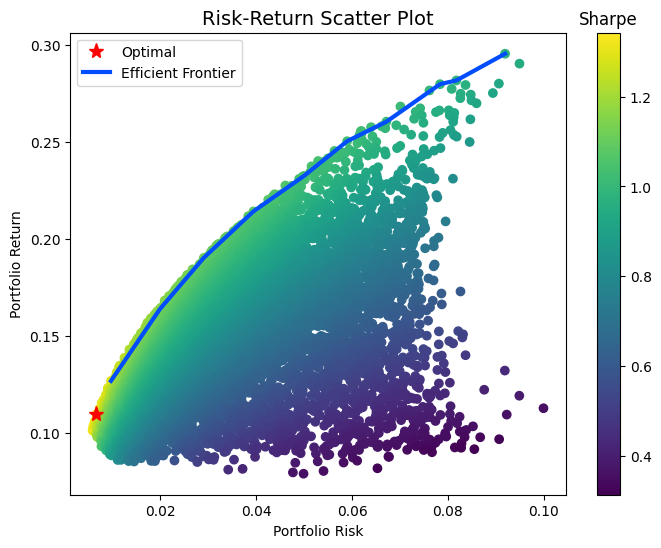

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import Series, DataFrame
from matplotlib import ticker
pd.options.display.max_columns = None
pd.set_option('display.width', 1000)
rng = np.random.default_rng()

#PARAMETERS
features = {
    "e1":"time","e2":"money","e3":"fulfilment","e4":"enjoyment","e5":"social"
}
correlations = {
    "e1e2":-0.6, "e1e3":0.1, "e1e4":0, "e1e5":0.15,
                 "e2e3":-0.2, "e2e4":-0.4, "e2e5":-0.4,
                             "e3e4":-0.15, "e3e5":0.1,
                                           "e4e5":0.2
}
elements = {
    "University":{features["e1"]:-0.6,features["e2"]:0.4,features["e3"]:0.5,features["e4"]:0.3,features["e5"]:0.5},
    "Poker":{features["e1"]:-0.2,features["e2"]:-0.2,features["e3"]:0.05,features["e4"]:0.5,features["e5"]:0.4},
    "Leetcode":{features["e1"]:-0.1,features["e2"]:0.2,features["e3"]:0.15,features["e4"]:-0.4,features["e5"]:-0.5},
    "Chess":{features["e1"]:-0.2,features["e2"]:-0.1,features["e3"]:0.05,features["e4"]:0.5,features["e5"]:0.1},
}
returnWeights = {
    features["e1"]:0.25, features["e2"]:0.25, features["e3"]:0.3, features["e4"]:0.1, features["e5"]:0.1
} #perceived importance of each feature in our return calculation

riskWeights = {
    features["e1"]:0.2, features["e2"]:0.35, features["e3"]:0.25, features["e4"]:0.1, features["e5"]:0.1
} #perceived importance of each feature in our risk calculation


#CONSTRUCTING THE SPACE
G = np.matrix([[1, correlations["e1e2"], correlations["e1e3"], correlations["e1e4"], correlations["e1e5"]],
               [correlations["e1e2"],1,correlations["e2e3"],correlations["e2e4"],correlations["e2e5"]],
               [correlations["e1e3"],correlations["e2e3"],1,correlations["e3e4"],correlations["e3e5"]],
               [correlations["e1e4"],correlations["e2e4"],correlations["e3e4"],1,correlations["e4e5"]],
               [correlations["e1e5"],correlations["e2e5"],correlations["e3e5"],correlations["e4e5"],1]
               ])
print(f"Gram = \n{G} \n")

eigs = np.linalg.eigvals(G)
if all(i > 0 for i in eigs):
    print(f"Gram is positive definite with eigenvalues: {eigs} \n")
    B = np.linalg.cholesky(G).T
    #print(f"B = {B} \n---\n")
elif any(i <= 0 for i in eigs):
    print(f"Gram is not positive definite, eigenvalues: {eigs} \n")

B = np.array(B)
dfc = DataFrame.from_dict(elements, columns = features.values(), orient = "index") #elements in conceptual basis; columns of B.
dfc.index.name = "Element"
dfc.columns.name = "Conceptual, B"
print(f"{dfc} \n")

def rn(row):
    res = np.dot(B,row.values)
    return Series(res)
dfs = dfc.apply(rn,axis = 1) #elements in standard Euclidean, Rn.
dfs.columns.name = "Standard, Rn"
#print(f"{dfs} \n---\n")

#RISK & RETURN
rr = DataFrame({
    "Return":(dfc.map(lambda x: max(x,0))*returnWeights).sum(axis = 1),
    "Risk":(dfc.map(lambda x: min(x,0))*-1*riskWeights).sum(axis = 1)})
print(f"{rr} \n")

corr = np.zeros((len(elements),len(elements)))
cov =  np.zeros((len(elements),len(elements)))
for i,vi in enumerate(dfs.index):
    for j,vj in enumerate(dfs.iloc[i:,:].index):
        corr[i,j+i] = np.dot(np.array(dfs.loc[vi,:]),dfs.loc[vj,:])/(np.linalg.norm(dfs.loc[vi,:])*np.linalg.norm(dfs.loc[vj,:]))
        cov[i,j+i] = np.sqrt(rr.loc[vi,"Risk"])*np.sqrt(rr.loc[vj,"Risk"])*corr[i,j+i]
corr, cov = corr + corr.T - np.diag(np.diag(corr)), cov + cov.T - np.diag(np.diag(cov))
print(f"Correlations\n{DataFrame(corr.round(3), index = elements.keys(), columns = elements.keys())} \n")
#print(f"Covariance\n{DataFrame(cov, index = elements.keys(), columns = elements.keys())} \n")

noPorts = 10000 #number of portfolios to simulate

rand = rng.random(size = (len(elements), noPorts))
portWeights = rand/rand.sum(axis = 0) #portWeights.sum() = 1; each column is a set of weights
ports = DataFrame({"Portfolio Return":np.dot(rr["Return"],portWeights),
                   "Portfolio Risk":np.diag(portWeights.T @ cov @ portWeights)},
                  index = [tuple(x) for x in portWeights.T.round(3)])
ports["Sharpe"] = ports["Portfolio Return"]/np.sqrt(ports["Portfolio Risk"])
ports.sort_values("Sharpe", ascending = False, inplace = True)
ports.index.name = "Weights"
with pd.option_context("display.max_rows", 8):
    print(ports.round(3))
print(f"\nRisk-Return correlation coefficient: {ports.loc[:,:"Portfolio Risk"].corr().iloc[0,1].round(3)}")

bins = np.arange(np.floor(ports["Portfolio Risk"].min()*100)/100, np.ceil(ports["Portfolio Risk"].max()*100)/100 + 0.01, 0.01)
ports["Risk bins"] = pd.cut(ports["Portfolio Risk"],bins)
frontier = ports.loc[ports.groupby("Risk bins", observed = True)["Portfolio Return"].idxmax(),"Portfolio Return":"Portfolio Risk"]

#PLOT
fig, ax = plt.subplots()
fig.set_figheight(6), fig.set_figwidth(8)
plot1 = ax.scatter(ports["Portfolio Risk"], ports["Portfolio Return"], c = ports["Sharpe"])
optimal, = ax.plot(ports.iloc[:1,1], ports.iloc[:1,0], marker = "*", color = "#ff0000", markersize = 11, label = "Optimal")
effFrontier, = ax.plot(frontier["Portfolio Risk"], frontier["Portfolio Return"], color = "#004cff", linewidth = 3, label = "Efficient Frontier")
ax.legend(handles = [optimal,effFrontier], loc = "best").legend_handles[0].set_linestyle("None")
ax.set_title("Risk-Return Scatter Plot", fontdict = {"fontsize":14})
ax.set_xlabel("Portfolio Risk"), ax.set_ylabel("Portfolio Return")
clb = fig.colorbar(plot1)
clb.ax.set_title("Sharpe");

## 5. The Challenge of Obtaining Meaningful Data

As stated in the disclaimer near the start of this document, to construct the space and also draw conclusions about the relative risks and returns of elements and portfolios within it, we must obtain three critical sets of data:
1. Correlation values ($\in [-1, 1]$) for each pair of features, $e_i,e_j \in B$.
2. Position vectors for each element in our conceptual basis $B$.
3. Weights for risk and return metrics, $\omega$, to determine perceived relative importance of each feature in our calculation.

Converting such qualitative data and subjective notions into quantitative measures we can draw meaningful conclusions from is not trivial and the most inherently flawed part of this modelling process. And whilst the values used in the above example were chosen in a discretionary manner, using this approach for anything more than illustrative purposes is likely to cause dispute between individuals who hold different qualitative and philosophical beliefs. Naturally the most sensible and fair way of collecting such data would be to use a suitably large sample.

This of course is not without its own problems and challenges. It would require widely agreed on definitions of each feature, activity and notion, and questions constructed in a way that are unambiguous as to what they are asking. Even if it were possible to construct such questions, the concepts required to frame those questions would be inherently complex and difficult to comprehend, for example what it means exactly for an activity to "reward you with time" is not something most people have ever had to associate a quantitative answer with.

So whilst a concrete set of questions allowing us to collect this necessary data in a fair and unbiased manner is beyond the scope of this document, the above does briefly introduce and explore some of the challenges and considerations when attempting to do so.

## Conclusion

In this document we have explored how techniques from linear algebra, finance, and statistics can be applied to construct quantitative notions of risk and return on qualitative data, and how this can be used to make informed decisions regarding resource allocation in non-quantitative fields.

We defined the five fundamental features describing our space along with their pairwise correlations, before verifying positive definiteness of the Gram matrix and constructing, with the help of Cholesky factorisation, a basis with these correlations encoded in. We then went about defining notions of both risk and return for activities as a weighted sum of their negative or positive coordinates in our basis. We ensured this made sense conceptually by defining our features in a way that increasingly positive values were associated with increasingly positive characteristics, and vice versa. We extended these notions to the more relevant idea of a portfolio of activities by introducing the scalar product, correlation, and covariance. This is crucial to properly capturing effects activities have on one another's risk and return and on the portfolio itself. We then made this actionable by carrying out Monte-Carlo simulations to map the efficient frontier and optimal portfolio, and to observe the empirical correlations between portfolio risk and return. To conclude, we briefly discussed the inherent flaws of the modelling process and the challenges that arise from trying to collect unbiased and meaningful data.

Throughout this document our examples have considered only one field described by one set of features and risk-return metrics defined by only one set of weights. Depending on the field being studied, its important characteristics, the activities within that field, and more; your set of features, their correlations, your risk-return weights, and all other parameters will vary. What means to be said is that whilst we cannot cover all the possible use cases, this document outlines a framework for a model that given a set of parameters and elements can produce quantitative outputs allowing us to draw conclusions not immediately obvious from the qualitative data alone.